In [ ]:
!pip install transformers datasets conllu accelerate -q

In [ ]:
import os
import urllib.request
import gc
import random

import conllu
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import TrainingArguments, Trainer

In [ ]:
treebanks = {
    "French": {
        "repo": "UD_French-Sequoia",
        "prefix": "fr_sequoia",
    },
    "English": {
        "repo": "UD_English-EWT",
        "prefix": "en_ewt",
    },
    "Finnish": {
        "repo": "UD_Finnish-TDT",
        "prefix": "fi_tdt",
    },
    "Arabic": {
        "repo": "UD_Arabic-PADT",
        "prefix": "ar_padt",
    },
    "Chinese": {
        "repo": "UD_Chinese-GSD",
        "prefix": "zh_gsd",
    },
}

os.makedirs("ud_data", exist_ok=True)

for lang, info in treebanks.items():
    for split in ["train", "dev", "test"]:
        filename = f'{info["prefix"]}-ud-{split}.conllu'
        url = f'https://raw.githubusercontent.com/UniversalDependencies/{info["repo"]}/master/{filename}'
        path = os.path.join("ud_data", filename)

        if not os.path.exists(path):
            urllib.request.urlretrieve(url, path)

        print("Downloaded:", path)

Downloaded: ud_data/fr_sequoia-ud-train.conllu
Downloaded: ud_data/fr_sequoia-ud-dev.conllu
Downloaded: ud_data/fr_sequoia-ud-test.conllu
Downloaded: ud_data/en_ewt-ud-train.conllu
Downloaded: ud_data/en_ewt-ud-dev.conllu
Downloaded: ud_data/en_ewt-ud-test.conllu
Downloaded: ud_data/fi_tdt-ud-train.conllu
Downloaded: ud_data/fi_tdt-ud-dev.conllu
Downloaded: ud_data/fi_tdt-ud-test.conllu
Downloaded: ud_data/ar_padt-ud-train.conllu
Downloaded: ud_data/ar_padt-ud-dev.conllu
Downloaded: ud_data/ar_padt-ud-test.conllu
Downloaded: ud_data/zh_gsd-ud-train.conllu
Downloaded: ud_data/zh_gsd-ud-dev.conllu
Downloaded: ud_data/zh_gsd-ud-test.conllu


In [ ]:
model_checkpoint = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def merge_multiword_tokens_from_conllu(sentence):
    new_words = []
    new_labels = []
    skip_ids = set()

    for token in sentence:
        token_id = token["id"]

        if isinstance(token_id, tuple) and token_id[1] == "-":
            start, _, end = token_id

            parts = [
                t for t in sentence
                if isinstance(t["id"], int) and start <= t["id"] <= end
            ]

            new_words.append(token["form"].replace(" ", ""))
            new_labels.append("+".join(t["upos"] for t in parts))

            for t in parts:
                skip_ids.add(t["id"])

        elif isinstance(token_id, int) and token_id not in skip_ids:
            new_words.append(token["form"].replace(" ", ""))
            new_labels.append(token["upos"])

    return new_words, new_labels

In [ ]:
RANDOM_SEED = 42

def load_conllu_normalized(filename, max_sentences=None, random_sample=False):
    sents = conllu.parse(open(filename, encoding="utf-8").read())

    if max_sentences is not None and len(sents) > max_sentences:
        if random_sample:
            rng = random.Random(RANDOM_SEED)
            sents = rng.sample(sents, max_sentences)
        else:
            sents = sents[:max_sentences]

    sentences = []
    labels = []

    for sent in sents:
        words, labs = merge_multiword_tokens_from_conllu(sent)
        sentences.append(words)
        labels.append(labs)

    return sentences, labels

In [ ]:
# Q11
def tokenize_and_align_labels(sentences, labels):
    tokenized = tokenizer(
        sentences,
        is_split_into_words=True,
        return_offsets_mapping=True,
        padding=True,
        truncation=True,
    )

    aligned_labels = []

    for i, sentence_labels in enumerate(labels):
        offsets = tokenized["offset_mapping"][i]
        word_ids = tokenized.word_ids(batch_index=i)

        label_sequence = []

        for offset, word_id in zip(offsets, word_ids):
            start, end = offset

            if word_id is None:
                label_sequence.append("<pad>")
            elif start == 0:
                label_sequence.append(sentence_labels[word_id])
            else:
                label_sequence.append("<pad>")

        aligned_labels.append(label_sequence)

    tokenized.pop("offset_mapping")
    tokenized["labels"] = aligned_labels

    return tokenized

In [ ]:
#Q13
def encode_labels(label_sequences):
    unique_labels = sorted({
        label
        for sequence in label_sequences
        for label in sequence
        if label != "<pad>"
    })

    label2id = {label: i for i, label in enumerate(unique_labels)}
    label2id["<pad>"] = -100

    id2label = {i: label for label, i in label2id.items() if i != -100}

    encoded_labels = [
        [label2id[label] for label in sequence]
        for sequence in label_sequences
    ]

    return encoded_labels, label2id, id2label

In [ ]:
# shared label mapping for all 5 languages
all_original_labels = []

for lang, info in treebanks.items():
    for split in ["train", "dev", "test"]:
        filename = f'{info["prefix"]}-ud-{split}.conllu'
        path = os.path.join("ud_data", filename)

        _, labels = load_conllu_normalized(path)
        all_original_labels.extend(labels)

_, label2id, id2label = encode_labels(all_original_labels)
label2id_model = {label: i for label, i in label2id.items() if i != -100}

print("Number of labels:", len(id2label))
print(label2id)

Number of labels: 137
{'ADJ': 0, 'ADJ+ADP': 1, 'ADJ+ADP+NOUN': 2, 'ADJ+ADP+PRON': 3, 'ADJ+PART': 4, 'ADJ+PRON': 5, 'ADP': 6, 'ADP+ADJ': 7, 'ADP+ADJ+PRON': 8, 'ADP+ADP': 9, 'ADP+CCONJ': 10, 'ADP+DET': 11, 'ADP+NOUN': 12, 'ADP+NOUN+ADP': 13, 'ADP+NOUN+DET': 14, 'ADP+NOUN+PRON': 15, 'ADP+NUM': 16, 'ADP+PART': 17, 'ADP+PRON': 18, 'ADP+PROPN': 19, 'ADP+SCONJ': 20, 'ADP+SCONJ+PART': 21, 'ADP+SCONJ+PRON': 22, 'ADP+X': 23, 'ADV': 24, 'ADV+ADP': 25, 'ADV+AUX': 26, 'ADV+DET': 27, 'ADV+PART': 28, 'AUX': 29, 'AUX+AUX': 30, 'AUX+PART': 31, 'AUX+PART+VERB': 32, 'AUX+PRON': 33, 'AUX+VERB': 34, 'AUX+VERB+PRON': 35, 'CCONJ': 36, 'CCONJ+ADJ': 37, 'CCONJ+ADJ+PRON': 38, 'CCONJ+ADP': 39, 'CCONJ+ADP+ADJ': 40, 'CCONJ+ADP+ADP': 41, 'CCONJ+ADP+CCONJ': 42, 'CCONJ+ADP+CCONJ+DET': 43, 'CCONJ+ADP+DET': 44, 'CCONJ+ADP+NOUN': 45, 'CCONJ+ADP+NOUN+PRON': 46, 'CCONJ+ADP+PART': 47, 'CCONJ+ADP+PRON': 48, 'CCONJ+ADP+SCONJ': 49, 'CCONJ+ADP+SCONJ+PRON': 50, 'CCONJ+ADV': 51, 'CCONJ+AUX': 52, 'CCONJ+AUX+AUX': 53, 'CCONJ+AUX+V

In [ ]:
# Q14 generalized
def create_dataset_from_conllu(
    filename,
    label2id=None,
    max_sentences=None,
    random_sample=False
):
    sentences, gold_labels = load_conllu_normalized(
        filename,
        max_sentences=max_sentences,
        random_sample=random_sample
    )

    tokenized = tokenize_and_align_labels(sentences, gold_labels)
    aligned_labels = tokenized["labels"]

    if label2id is None:
        encoded_labels, label2id, _ = encode_labels(aligned_labels)
    else:
        encoded_labels = [
            [label2id[label] for label in labels]
            for labels in aligned_labels
        ]

    data = []

    for i in range(len(sentences)):
        data.append({
            "input_ids": tokenized["input_ids"][i],
            "attention_mask": tokenized["attention_mask"][i],
            "labels": encoded_labels[i],
        })

    return Dataset.from_list(data), label2id

In [24]:
# all dataset
datasets_by_lang = {}

for lang, info in treebanks.items():
    datasets_by_lang[lang] = {}

    for split in ["train", "dev", "test"]:
        filename = f'{info["prefix"]}-ud-{split}.conllu'
        path = os.path.join("ud_data", filename)

        datasets_by_lang[lang][split], _ = create_dataset_from_conllu(
            path,
            label2id=label2id,
            max_sentences=None,
            random_sample=False
        )

        print(lang, split, datasets_by_lang[lang][split])

French train Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2231
})
French dev Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 412
})
French test Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 456
})
English train Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 12544
})
English dev Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2001
})
English test Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2077
})
Finnish train Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 12217
})
Finnish dev Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1364
})
Finnish test Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1555
})
Arabic train Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    n

In [25]:
# Q16
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    mask = labels != -100
    correct = (predictions == labels) & mask

    accuracy = correct.sum() / mask.sum()

    return {"accuracy": accuracy}

In [26]:
def make_training_args(output_dir):
    try:
        return TrainingArguments(
            output_dir=output_dir,
            evaluation_strategy="epoch",
            learning_rate=2e-5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            weight_decay=0.01,
            logging_steps=50,
            save_strategy="no",
            report_to="none",
        )
    except TypeError:
        return TrainingArguments(
            output_dir=output_dir,
            eval_strategy="epoch",
            learning_rate=2e-5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            num_train_epochs=3,
            weight_decay=0.01,
            logging_steps=50,
            save_strategy="no",
            report_to="none",
        )

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
# Q19 training and evaluation
save_root = "/content/drive/MyDrive/mbert_pos_models"
os.makedirs(save_root, exist_ok=True)

results = {}

for train_lang in treebanks.keys():
    print("\n" + "=" * 60)
    print("Training on:", train_lang)
    print("=" * 60)

    model = AutoModelForTokenClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(id2label),
        id2label=id2label,
        label2id=label2id_model,
    )

    training_args = make_training_args(f"mbert-pos-{train_lang}")

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=datasets_by_lang[train_lang]["train"],
        eval_dataset=datasets_by_lang[train_lang]["dev"],
        compute_metrics=compute_metrics,
    )

    trainer.train()

    results[train_lang] = {}

    for test_lang in treebanks.keys():
        metrics = trainer.evaluate(datasets_by_lang[test_lang]["test"])
        acc = metrics["eval_accuracy"]
        results[train_lang][test_lang] = acc

        print(f"{train_lang} -> {test_lang}: {acc:.4f}")

    save_dir = os.path.join(save_root, f"mbert-pos-{train_lang}")
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("Saved model to:", save_dir)

    del trainer
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Training on: French


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly ini

Epoch,Training Loss,Validation Loss,Accuracy
1,0.467877,0.154869,0.970773
2,0.112580,0.089726,0.980447
3,0.067353,0.082046,0.983534


French -> French: 0.9838
French -> English: 0.7397
French -> Finnish: 0.8152
French -> Arabic: 0.5593
French -> Chinese: 0.6460


...

BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly ini

Epoch,Training Loss,Validation Loss,Accuracy
1,0.282190,0.229775,0.934228
2,0.191712,0.180683,0.947651
3,0.140597,0.177261,0.950730


Chinese -> French: 0.7017
Chinese -> English: 0.6850
Chinese -> Finnish: 0.7407
Chinese -> Arabic: 0.4110
Chinese -> Chinese: 0.9550


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /content/drive/MyDrive/mbert_pos_models/mbert-pos-Chinese


In [28]:
matrix = pd.DataFrame(results).T
matrix = matrix.loc[list(treebanks.keys()), list(treebanks.keys())]

matrix.round(4)

,French,English,Finnish,Arabic,Chinese
French,0.9838,0.7397,0.8152,0.5593,0.6460
English,0.8507,0.9701,0.8512,0.4607,0.6597
Finnish,0.6337,0.6289,0.9677,0.5105,0.6597
Arabic,0.6204,0.5601,0.5968,0.9529,0.5031
Chinese,0.7017,0.6850,0.7407,0.4110,0.9550


In [29]:
print(matrix.round(4).to_latex())

\begin{tabular}{lrrrrr}
\toprule
 & French & English & Finnish & Arabic & Chinese \\
\midrule
French & 0.983800 & 0.739700 & 0.815200 & 0.559300 & 0.646000 \\
English & 0.850700 & 0.970100 & 0.851200 & 0.460700 & 0.659700 \\
Finnish & 0.633700 & 0.628900 & 0.967700 & 0.510500 & 0.659700 \\
Arabic & 0.620400 & 0.560100 & 0.596800 & 0.952900 & 0.503100 \\
Chinese & 0.701700 & 0.685000 & 0.740700 & 0.411000 & 0.955000 \\
\bottomrule
\end{tabular}



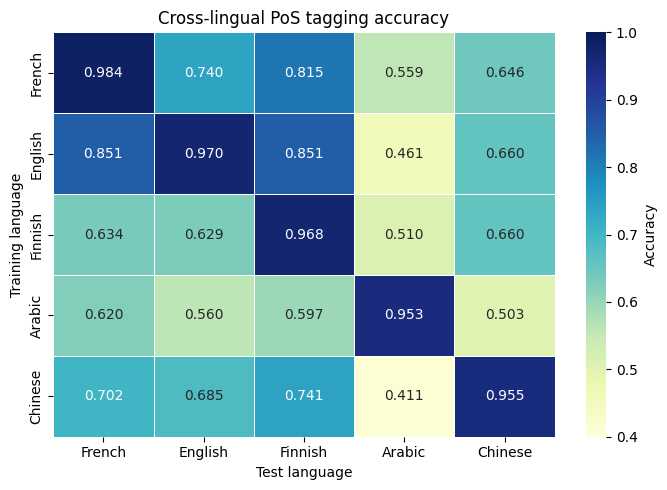

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

matrix = pd.DataFrame(
    [
        [0.9838, 0.7397, 0.8152, 0.5593, 0.6460],
        [0.8507, 0.9701, 0.8512, 0.4607, 0.6597],
        [0.6337, 0.6289, 0.9677, 0.5105, 0.6597],
        [0.6204, 0.5601, 0.5968, 0.9529, 0.5031],
        [0.7017, 0.6850, 0.7407, 0.4110, 0.9550],
    ],
    index=["French", "English", "Finnish", "Arabic", "Chinese"],
    columns=["French", "English", "Finnish", "Arabic", "Chinese"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.4,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Accuracy"}
)

plt.xlabel("Test language")
plt.ylabel("Training language")
plt.title("Cross-lingual PoS tagging accuracy")
plt.tight_layout()
plt.savefig("q19_transfer_heatmap.png", dpi=300)
plt.show()